## 0. Setup

Run this cell once to install the kviz package onto the Python path
and to confirm the deep-learning libraries are available.

In [73]:
import base64
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, Image, display


kviz_pkg_root = (Path.cwd() / "kviz-library" / "kviz").resolve()
if str(kviz_pkg_root) not in sys.path:
    sys.path.insert(0, str(kviz_pkg_root))

# Evict any previously-cached kviz (e.g. an older copy installed in
# site-packages) so the local vendored kviz-library/kviz/kviz wins.
# Without this, re-running this cell after editing kviz/__init__.py is a
# no-op because Python keeps the first-imported module in sys.modules.
for _name in [m for m in list(sys.modules) if m == "kviz" or m.startswith("kviz.")]:
    del sys.modules[_name]

import kviz  
from kviz import Visualizer, NetworkArchitectureVisualizer

import tensorflow as tf  
from tensorflow import keras  
layers = keras.layers

RNG = np.random.default_rng(506)
tf.random.set_seed(506)
keras.utils.set_random_seed(506)

warnings.filterwarnings(
    "ignore",
    message=".*Do not pass an `input_shape`/`input_dim`.*",
)


# put all kviz visualizations in a single folder
VIZ_DIR = Path("visualizations")
VIZ_DIR.mkdir(exist_ok=True)


# small helpers for inline display of generated PNGs / GIFs 

def _embed_data_uri(path: str | Path) -> str:
    """Read a local image / gif and return a base64 data URI."""
    p = Path(path)
    ext = p.suffix.lstrip(".").lower()
    if ext == "jpg":
        ext = "jpeg"
    return f"data:image/{ext};base64,{base64.b64encode(p.read_bytes()).decode('ascii')}"


def show_grid(rows: list[list[str]], headers: list[str] | None = None, max_width: int = 280):
    
    html = ["<table style='border-collapse:collapse;'>"]
    if headers:
        html.append("<tr>" + "".join(
            f"<th style='padding:6px 10px;text-align:center;font-family:monospace;'>{h}</th>"
            for h in headers
        ) + "</tr>")
    for row in rows:
        html.append("<tr>")
        for cell in row:
            html.append(
                f"<td style='padding:4px;text-align:center;vertical-align:top;'>"
                f"<img src='{_embed_data_uri(cell)}' style='max-width:{max_width}px;height:auto;' />"
                f"</td>"
            )
        html.append("</tr>")
    html.append("</table>")
    display(HTML("".join(html)))


print("kviz at:", kviz.__file__)
print("tensorflow:", tf.__version__)
print("keras:", keras.__version__)

kviz at: /Users/eeshwargattupalli/Documents/CS 506 TA/Lab Proposals/Lab12-2/kviz-library/kviz/kviz/__init__.py
tensorflow: 2.21.0
keras: 3.14.0


### 1. Loading and exploring dataset

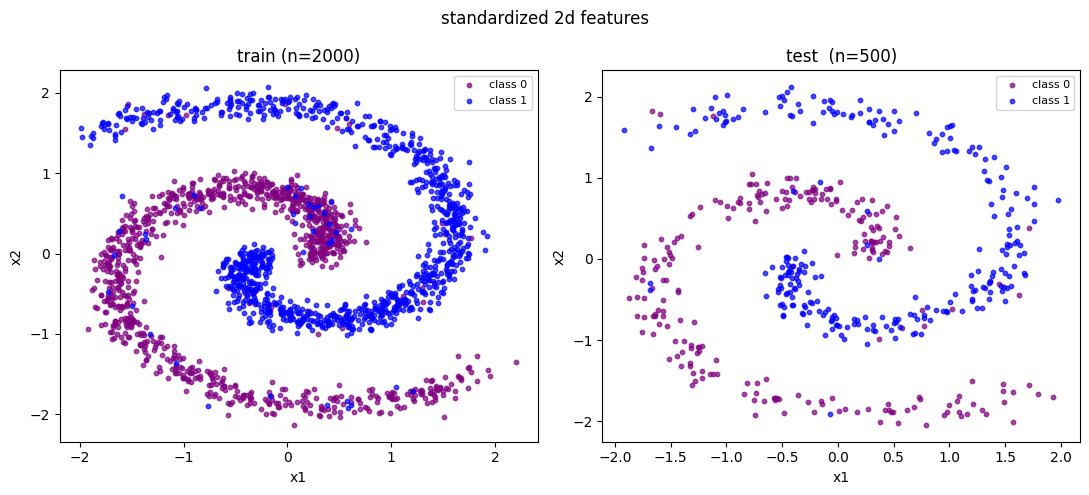

((2000, 2), (500, 2), 0.492, 0.522)

In [74]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

X_train = df_train[["x1", "x2"]].to_numpy(dtype=np.float32)
y_train = df_train["y"].to_numpy(dtype=np.int64)
X_test = df_test[["x1", "x2"]].to_numpy(dtype=np.float32)
y_test = df_test["y"].to_numpy(dtype=np.int64)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, X, y, name in [
    (axes[0], X_train, y_train, f"train (n={len(y_train)})"),
    (axes[1], X_test, y_test, f"test  (n={len(y_test)})"),
]:
    ax.scatter(X[y == 0, 0], X[y == 0, 1], s=10, alpha=0.7, label="class 0", color="purple")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], s=10, alpha=0.7, label="class 1", color="blue")
    ax.set_title(name)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.legend(loc="best", fontsize=8)
fig.suptitle("standardized 2d features")
plt.tight_layout()
plt.show()

X_train.shape, X_test.shape, float(y_train.mean()), float(y_test.mean())

## 2. Activation Functions

Without nonlinearities, stacking dense layers collapses into a single
linear map. The activation function is what gives a network the
ability to bend space. We'll compare four common choices on a *tiny*
network (one hidden layer, 8 units) so the differences are easy to see:

| Activation | What it looks like                              | Common pitfalls                |
|------------|-------------------------------------------------|--------------------------------|
| `relu`     | $\max(0, x)$ — piecewise linear                 | "Dead" neurons (always 0)      |
| `tanh`     | $\frac{e^x - e^{-x}}{e^x + e^{-x}}$, in $[-1, 1]$ | Saturates for large $\text{abs}(x)$     |
| `sigmoid`  | $\frac{1}{1 + e^{-x}}$, in $[0, 1]$              | Saturates badly; vanishing gradient|
| `gelu`     | smooth ReLU-ish ($x\,\Phi(x)$)                  | More compute than ReLU         |

Below, `build_model` gives you a single knob each for activation and
architecture.

In [75]:
def build_model(hidden_sizes, activation, lr: float = 1e-2):
    """
    Sequential MLP for binary classification on 2D inputs.
    """
    model = keras.Sequential()
    model.add(layers.Dense(hidden_sizes[0], input_dim=2, activation=activation))
    for h in hidden_sizes[1:]:
        model.add(layers.Dense(h, activation=activation))
    model.add(layers.Dense(1, activation="sigmoid"))
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="binary_crossentropy")
    return model


def fit_model(model, X, y, epochs: int = 80, batch_size: int = 128):
    model.fit(X, y, epochs=epochs, batch_size=batch_size, verbose=0)
    return model


def accuracy(model, X, y) -> float:
    p = (model.predict(X, verbose=0).reshape(-1) >= 0.5).astype(np.int64)
    return float((p == y).mean())


def plot_decision_boundary(model, X, y, ax, title: str = ""):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    Z = model.predict(grid, verbose=0).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, alpha=0.5, cmap="coolwarm_r")
    ax.scatter(X[y == 0, 0], X[y == 0, 1], s=8, color="purple", alpha=0.6)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], s=8, color="blue", alpha=0.6)
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

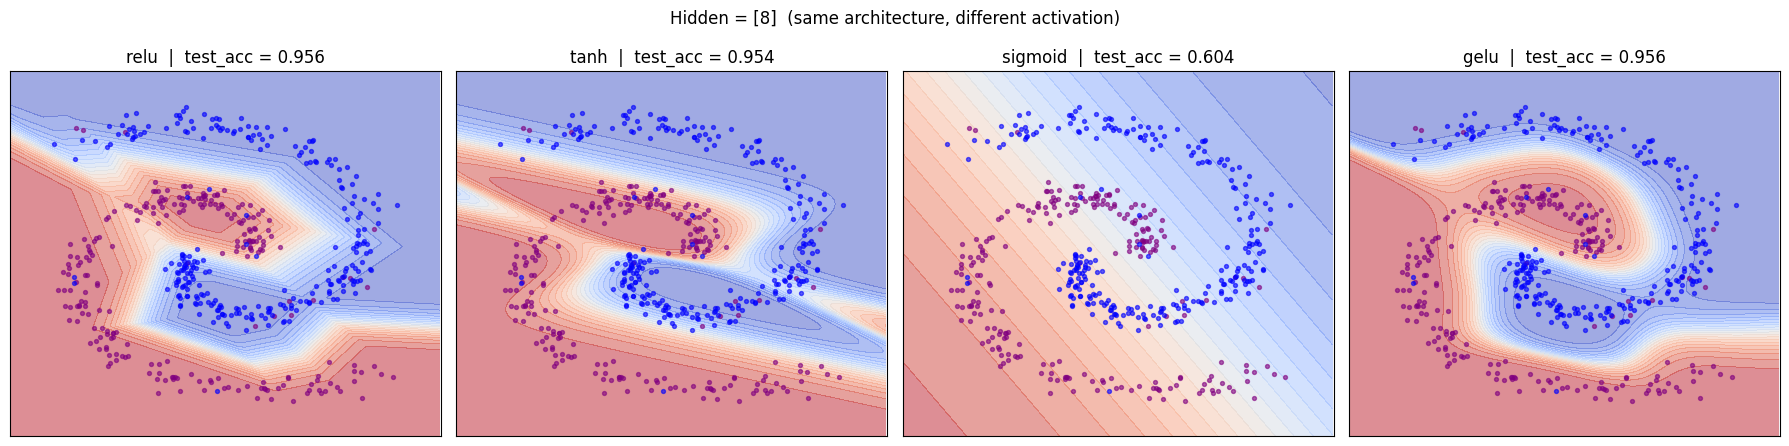

{'relu': 0.956, 'tanh': 0.954, 'sigmoid': 0.604, 'gelu': 0.956}

In [76]:
# Train a small 1-hidden-layer (8-unit) network with each activation,
# then plot the learned decision boundary side by side.
ACTIVATIONS = ["relu", "tanh", "sigmoid", "gelu"]
SMALL_HIDDEN = [8]

small_models = {}
small_accs = {}
for act in ACTIVATIONS:
    keras.utils.set_random_seed(506)
    m = build_model(SMALL_HIDDEN, act)
    fit_model(m, X_train, y_train, epochs=80)
    small_models[act] = m
    small_accs[act] = accuracy(m, X_test, y_test)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, act in zip(axes, ACTIVATIONS):
    plot_decision_boundary(
        small_models[act], X_test, y_test, ax,
        title=f"{act}  |  test_acc = {small_accs[act]:.3f}",
    )
fig.suptitle(f"Hidden = {SMALL_HIDDEN}  (same architecture, different activation)")
plt.tight_layout()
plt.show()

small_accs

### 2.1 — Looking inside the network with kviz

`Visualizer.render(...)` draws the architecture as a static graph
(useful for "before vs after" comparisons later).

`Visualizer.view_activations_for(X, y, ...)` makes a GIF where, for
each input point, every neuron is colored by its activation strength.
Watch the hidden layer "light up" differently for class-0 vs class-1
points — and notice how some ReLU neurons may stay completely dark
("dead") regardless of input.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Wrote: arch_<activation>.png and activations_<activation>.gif into visualizations


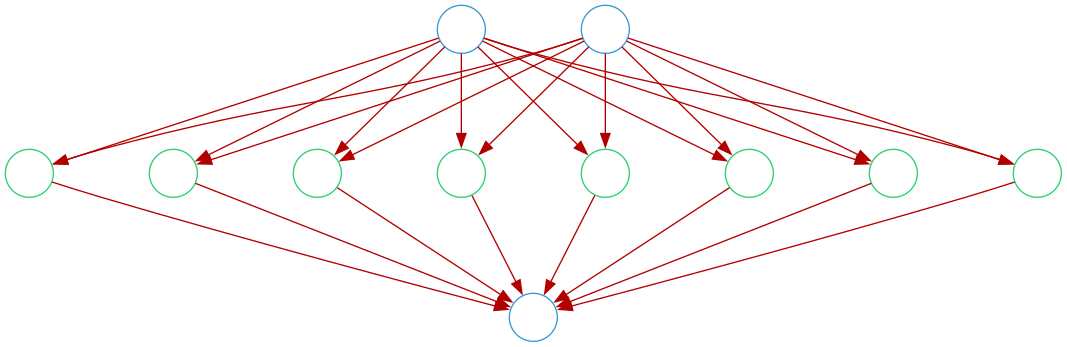

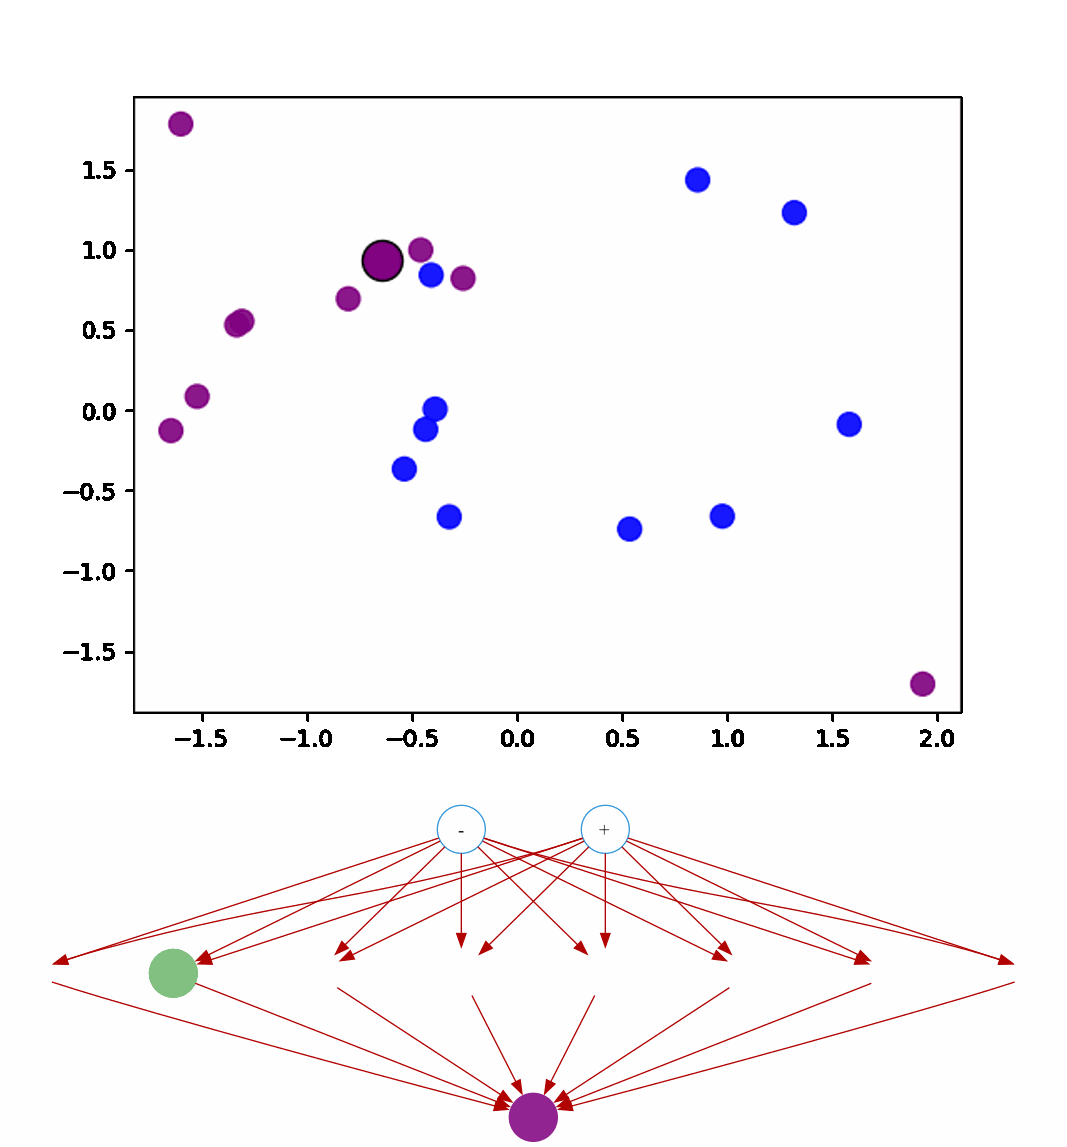

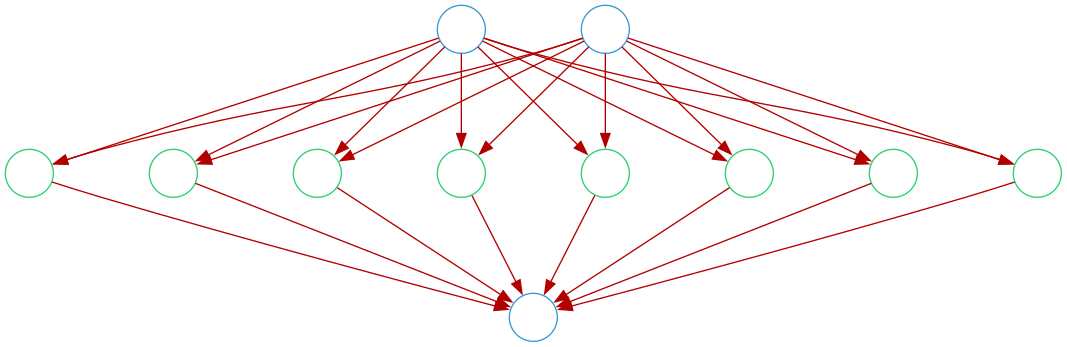

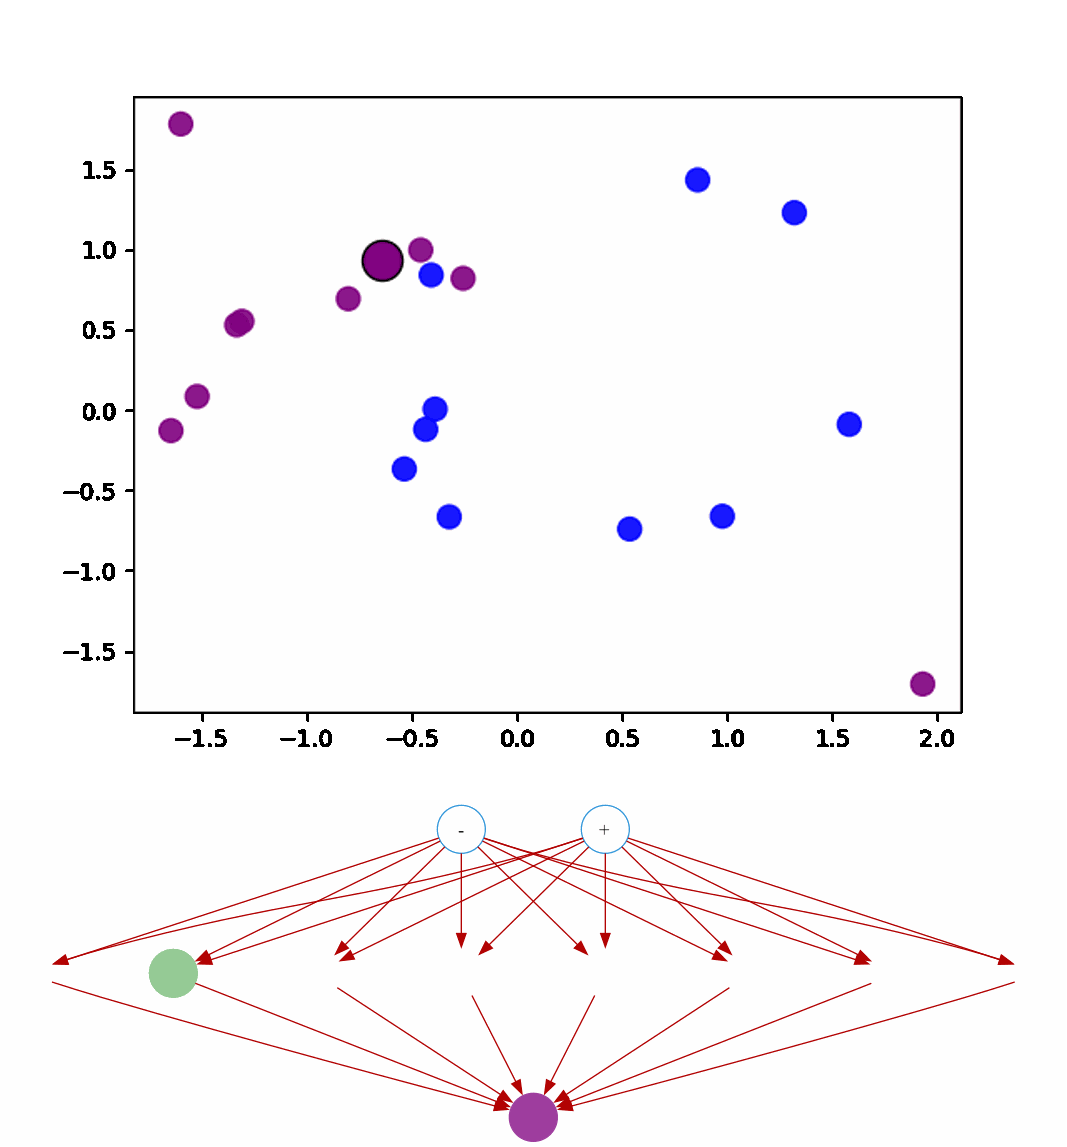

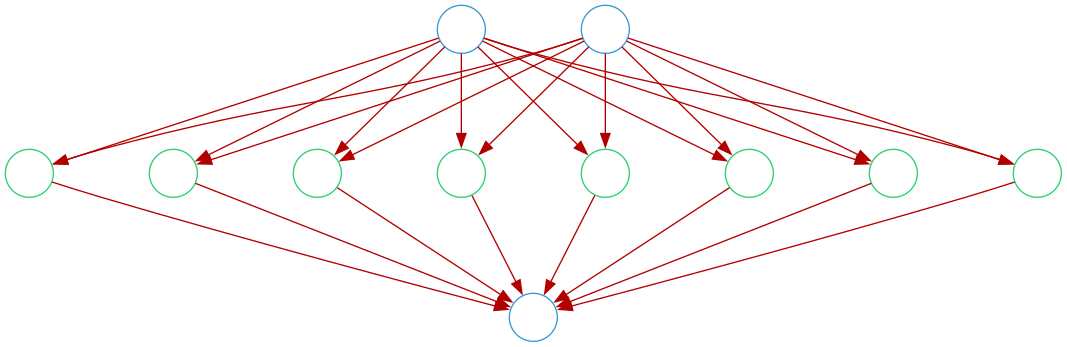

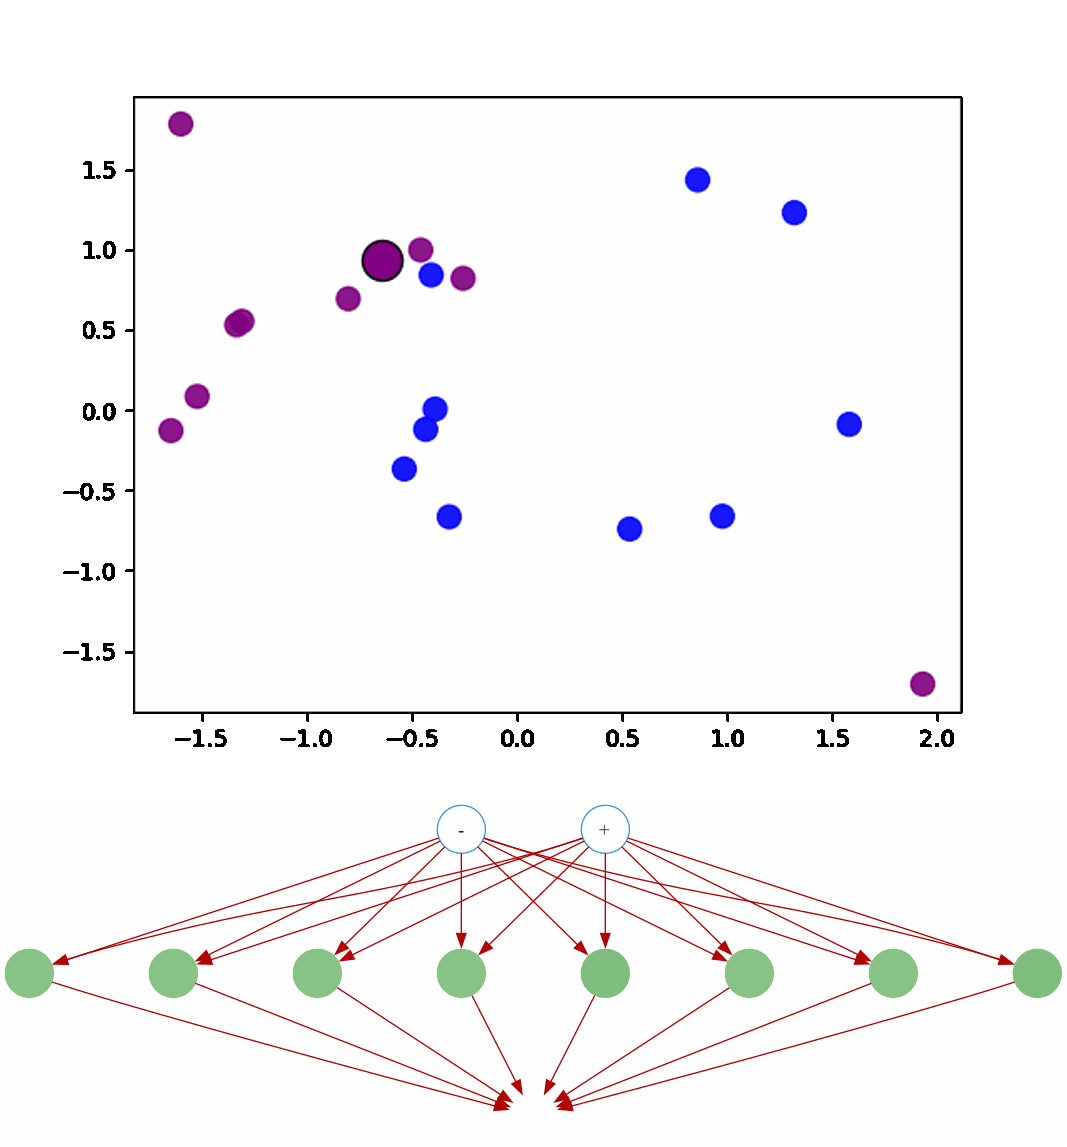

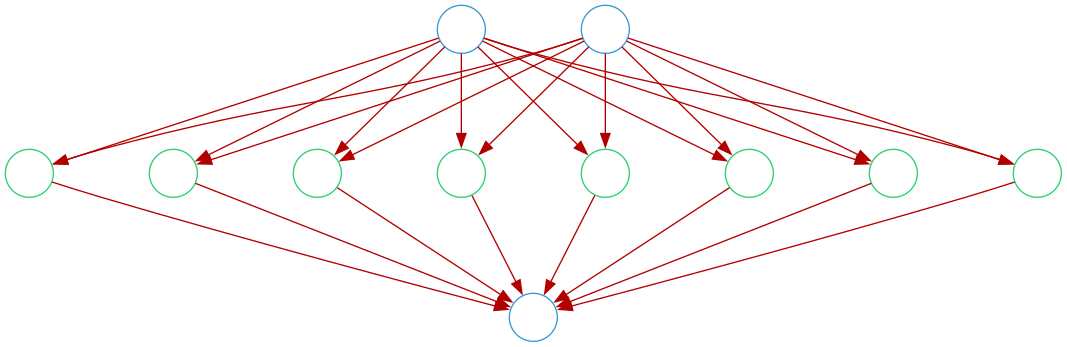

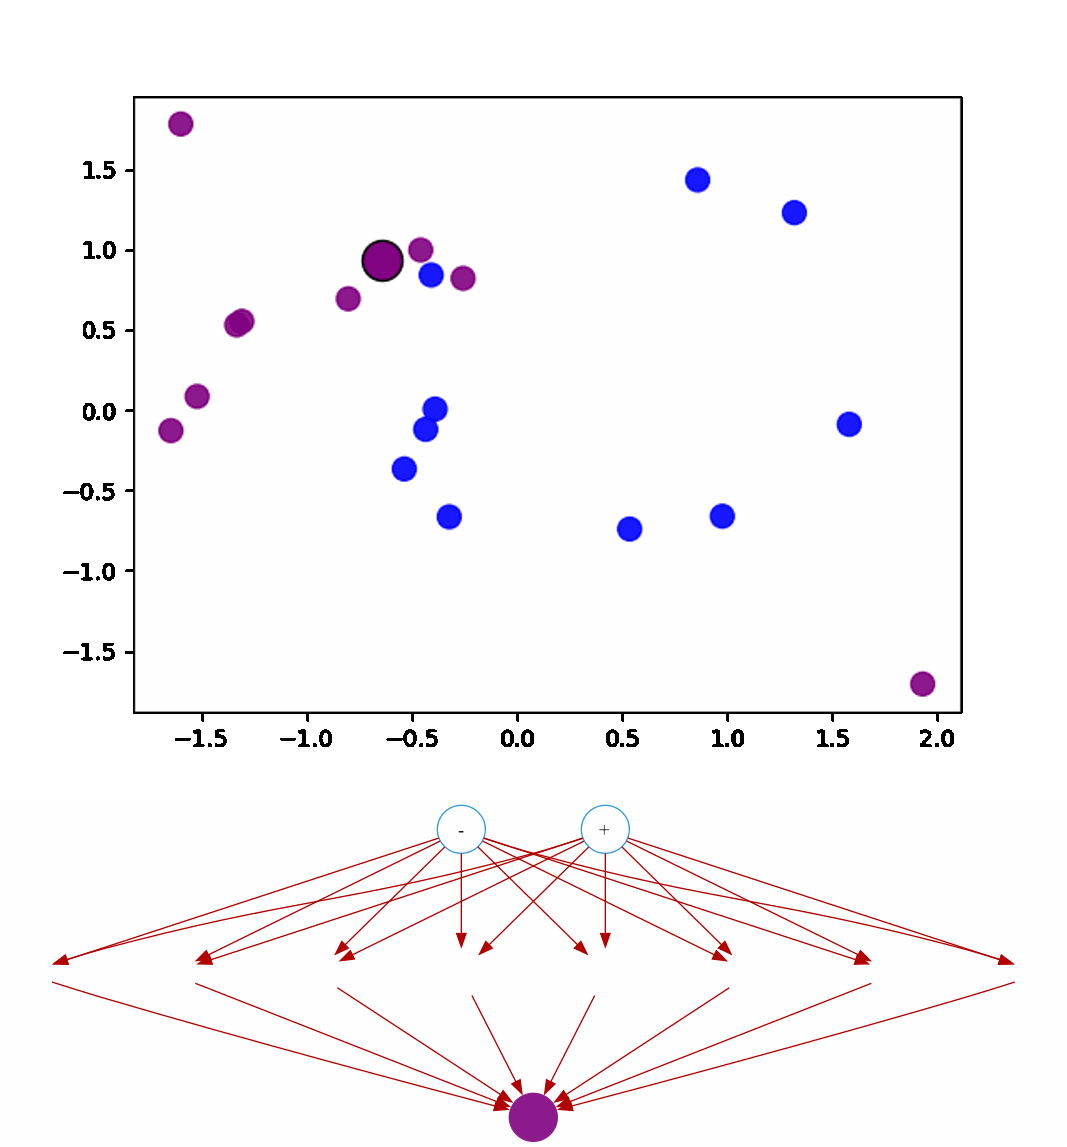

In [77]:
def balanced_subset(X, y, k_per_class: int = 10, seed: int = 0):
    rng = np.random.default_rng(seed)
    idx0 = rng.permutation(np.where(y == 0)[0])[:k_per_class]
    idx1 = rng.permutation(np.where(y == 1)[0])[:k_per_class]
    idx = np.concatenate([idx0, idx1])
    rng.shuffle(idx)
    return X[idx], y[idx]


X_view, y_view = balanced_subset(X_test, y_test, k_per_class=10, seed=12)

# Make the animation a bit slower (ms per frame)
ACTIVATION_GIF_MS = 550

# Render an architecture diagram + activation animation for each activation.
for act in ACTIVATIONS:
    viz = Visualizer(small_models[act])
    viz.render(filename=str(VIZ_DIR / f"arch_{act}"))
    viz.view_activations_for(
        X_view,
        y_view,
        filename=str(VIZ_DIR / f"activations_{act}"),
        duration=ACTIVATION_GIF_MS,
    )
print("Wrote: arch_<activation>.png and activations_<activation>.gif into", str(VIZ_DIR))

# Vertical scroll view: for each activation, show architecture then GIF.
# This is easier to read than a grid because you can focus on one
# activation at a time.
for act in ACTIVATIONS:
    display(HTML(f"<h4 style='font-family:monospace;margin:14px 0 6px 0;'>{act}</h4>"))
    display(Image(filename=str(VIZ_DIR / f"arch_{act}.png"), width=520))
    display(Image(filename=str(VIZ_DIR / f"activations_{act}.gif"), width=520))

### 2.2 — Layer-by-layer forward pass for a single input

`view_forward_pass_for` animates a
**single input** propagating through the network. Each frame shows the
next layer activating, with the previous layer mildly faded for
context.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Wrote: forward_pass_tanh.gif into visualizations


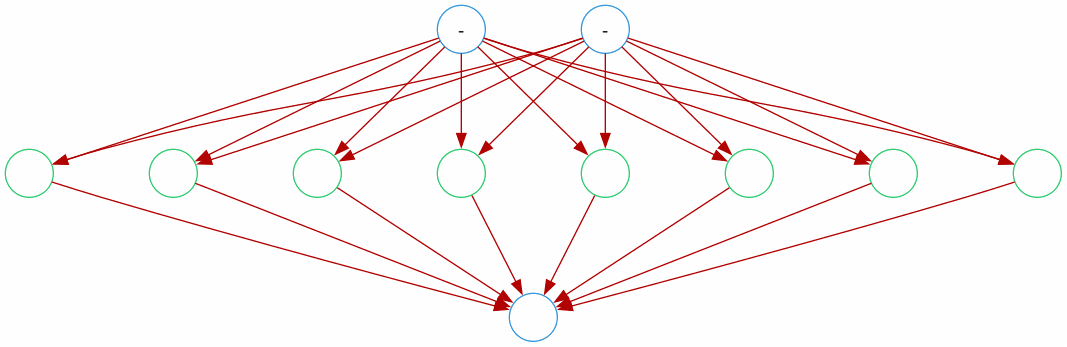

In [78]:
viz_fwd = Visualizer(small_models["tanh"])
single_input = X_test[0:1]  # shape (1, 2)
viz_fwd.view_forward_pass_for(
    single_input,
    filename=str(VIZ_DIR / "forward_pass_tanh"),
    duration=600,
    steps_per_layer=4,    # smoother in/out animation
    show_input_signs=True,
    fade_previous=True,
)
print("Wrote: forward_pass_tanh.gif into", str(VIZ_DIR))

# Display the GIF inline.
display(Image(filename=str(VIZ_DIR / "forward_pass_tanh.gif")))

## 3. Finding the Minimal Architecture

A bigger network usually fits better — but at what cost? We'll sweep
across activations and architectures and look for the **smallest** model
(fewest parameters) that still hits a target accuracy. That's the
"minimal architecture" we'll then try to beat with the compression
techniques in section 4.

In [79]:
ARCHITECTURES = [[2], [4], [8], [16], [8, 4], [16, 8], [32, 16]]

sweep_rows = []
for act in ACTIVATIONS:
    for hs in ARCHITECTURES:
        keras.utils.set_random_seed(506)
        m = build_model(hs, act)
        fit_model(m, X_train, y_train, epochs=80)
        sweep_rows.append({
            "activation": act,
            "hidden": str(hs),
            "params": int(m.count_params()),
            "train_acc": accuracy(m, X_train, y_train),
            "test_acc": accuracy(m, X_test, y_test),
        })

sweep_df = pd.DataFrame(sweep_rows).sort_values(
    ["test_acc", "params"], ascending=[False, True]
).reset_index(drop=True)
sweep_df.head(15)

,activation,hidden,params,train_acc,test_acc
0,relu,[16],65,0.9595,0.958
1,relu,"[8, 4]",65,0.9615,0.958
2,relu,"[16, 8]",193,0.9620,0.958
3,gelu,"[16, 8]",193,0.9605,0.958
4,relu,"[32, 16]",641,0.9620,0.958
5,gelu,"[32, 16]",641,0.9620,0.958
6,relu,[8],33,0.9570,0.956
7,gelu,[8],33,0.9600,0.956
8,tanh,[16],65,0.9580,0.956
9,tanh,"[8, 4]",65,0.9590,0.956


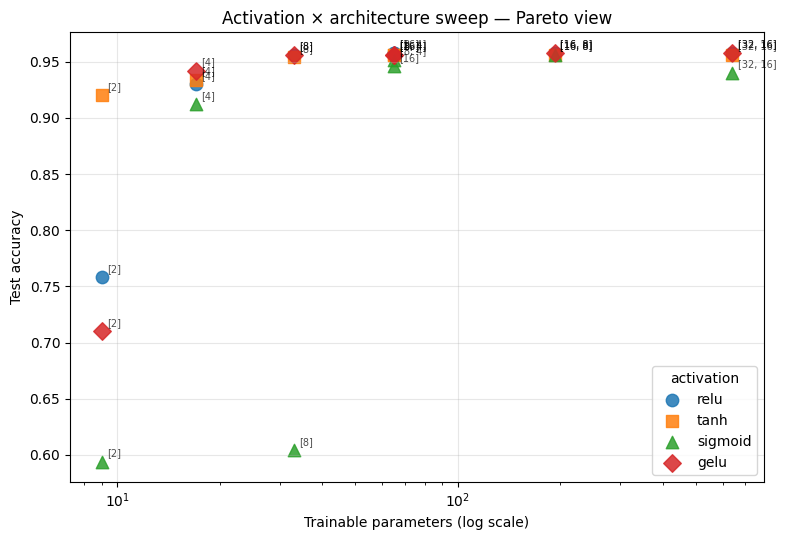

In [80]:
# Pareto plot: more parameters should buy more accuracy --- but only up to
# a point. The "frontier" tells us the smallest network at each accuracy.
fig, ax = plt.subplots(figsize=(8, 5.5))
markers = {"relu": "o", "tanh": "s", "sigmoid": "^", "gelu": "D"}
for act in ACTIVATIONS:
    sub = sweep_df[sweep_df.activation == act]
    ax.scatter(sub.params, sub.test_acc, label=act, s=80, marker=markers[act], alpha=0.85)
    for _, row in sub.iterrows():
        ax.annotate(row.hidden, (row.params, row.test_acc),
                    fontsize=7, alpha=0.7, xytext=(4, 4), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("Trainable parameters (log scale)")
ax.set_ylabel("Test accuracy")
ax.set_title("Activation × architecture sweep — Pareto view")
ax.grid(True, alpha=0.3)
ax.legend(title="activation")
plt.tight_layout()
plt.show()

In [81]:
TARGET_ACC = 0.92

# Smallest architecture (by params) that hits TARGET_ACC, per activation.
print(f"Minimal architectures to reach test_acc >= {TARGET_ACC:.2f}:\n")
for act in ACTIVATIONS:
    cand = sweep_df[(sweep_df.activation == act) & (sweep_df.test_acc >= TARGET_ACC)]
    cand = cand.sort_values("params")
    if len(cand):
        row = cand.iloc[0]
        print(f"  {act:8s}  hidden={row.hidden:<10}  params={row.params:>4}  test_acc={row.test_acc:.3f}")
    else:
        print(f"  {act:8s}  (none in sweep reach the target)")

best = sweep_df[sweep_df.test_acc >= TARGET_ACC].sort_values("params").iloc[0]
print(f"\nGlobal minimum: activation={best.activation}, hidden={best.hidden}, "
      f"params={best.params}, test_acc={best.test_acc:.3f}")

OPT_ACTIVATION = best.activation
OPT_HIDDEN = eval(best.hidden)
OPT_ACTIVATION, OPT_HIDDEN

Minimal architectures to reach test_acc >= 0.92:

  relu      hidden=[4]         params=  17  test_acc=0.930
  tanh      hidden=[2]         params=   9  test_acc=0.920
  sigmoid   hidden=[8, 4]      params=  65  test_acc=0.952
  gelu      hidden=[4]         params=  17  test_acc=0.942

Global minimum: activation=tanh, hidden=[2], params=9, test_acc=0.920


('tanh', [2])

> **TODO Minimal architecture.**
>
> 1. Pick a target test accuracy (`TARGET_ACC` above) that you think is
>    "good enough" for the spirals. Justify your choice in 1–2 sentences.
> 2. Report the *smallest* architecture from the sweep that hits your
>    target. Is the optimal activation function the same one you would
>    have picked from section 2?
>
> _Your answer:_

## 4. Architecture Minimization

The sweep above tells us the smallest model that *trains from scratch*
to a given accuracy. With three different tricks we can often do even
better, by *starting* from a bigger model and squeezing it down.

For each technique below, we'll start from the same baseline:

In [82]:
BASELINE_HIDDEN = [16, 8]
BASELINE_ACTIVATION = "tanh"

keras.utils.set_random_seed(506)
baseline = build_model(BASELINE_HIDDEN, BASELINE_ACTIVATION)
fit_model(baseline, X_train, y_train, epochs=120)

baseline_acc = accuracy(baseline, X_test, y_test)
baseline_params = int(baseline.count_params())

# Save a kviz architecture render for "before".
Visualizer(baseline).render(filename=str(VIZ_DIR / "arch_baseline"))

print("(baseline accuracy, baseline number of parameters)")
baseline_acc, baseline_params

(baseline accuracy, baseline number of parameters)


(0.958, 193)

### 4.1 — Pruning

**Idea.** After training, many weights have small magnitude — they
contribute little. Zeroing the smallest `s%` of weights ("magnitude
pruning") drops the model's effective parameter count *without* changing
its architecture. A short fine-tune recovers most of the lost accuracy.

In [83]:
def prune_dense_weights_inplace(model, sparsity: float):
    """Zero the smallest |w| in each Dense kernel until `sparsity` is reached."""
    new_weights = []
    for w in model.get_weights():
        if w.ndim == 2:
            k = int(w.size * sparsity)
            if k > 0:
                thresh = np.partition(np.abs(w).ravel(), k - 1)[k - 1]
                w = w * (np.abs(w) > thresh)
        new_weights.append(w)
    model.set_weights(new_weights)
    return model


def kernel_sparsity(model) -> float:
    z = total = 0
    for w in model.get_weights():
        if w.ndim == 2:
            z += int((w == 0).sum())
            total += w.size
    return z / max(total, 1)


def make_prune_masks(model: keras.Model, sparsity: float):
    """Return binary masks (same shapes as model.get_weights()).

    For Dense kernels (2D arrays) we keep the largest-magnitude weights and
    mask the rest to 0.
    """
    masks = []
    for w in model.get_weights():
        if w.ndim == 2:
            flat = np.abs(w).ravel()
            k = int(flat.size * sparsity)
            if k > 0:
                thresh = np.partition(flat, k - 1)[k - 1]
                mask = (np.abs(w) > thresh).astype(w.dtype)
            else:
                mask = np.ones_like(w, dtype=w.dtype)
            masks.append(mask)
        else:
            masks.append(np.ones_like(w))
    return masks


def apply_masks_inplace(model: keras.Model, masks):
    ws = model.get_weights()
    model.set_weights([w * m for w, m in zip(ws, masks)])
    return model


class EnforceMasks(keras.callbacks.Callback):
    """Keep pruned weights at exactly zero during fine-tuning."""

    def __init__(self, masks):
        super().__init__()
        self.masks = masks

    def on_train_batch_end(self, batch, logs=None):
        apply_masks_inplace(self.model, self.masks)


prune_rows = []
for s in [0.30, 0.50, 0.70, 0.90]:
    keras.utils.set_random_seed(506)
    m = build_model(BASELINE_HIDDEN, BASELINE_ACTIVATION)
    fit_model(m, X_train, y_train, epochs=120)

    pre = accuracy(m, X_test, y_test)

    masks = make_prune_masks(m, sparsity=s)
    apply_masks_inplace(m, masks)

    post = accuracy(m, X_test, y_test)
    sp_after_prune = kernel_sparsity(m)

    # Fine-tune *with mask enforcement* so zeros can't come back.
    m.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=128,
        verbose=0,
        callbacks=[EnforceMasks(masks)],
    )
    apply_masks_inplace(m, masks)

    post_ft = accuracy(m, X_test, y_test)
    sp_after_ft = kernel_sparsity(m)

    prune_rows.append({
        "target_sparsity": s,
        "sparsity_after_prune": sp_after_prune,
        "sparsity_after_finetune": sp_after_ft,
        "test_acc_before_prune": pre,
        "test_acc_after_prune": post,
        "test_acc_after_finetune": post_ft,
    })

    if abs(s - 0.50) < 1e-9:
        pruned_50 = m  # this one is *actually* sparse after fine-tune

pd.DataFrame(prune_rows).round(4)

,target_sparsity,sparsity_after_prune,sparsity_after_finetune,test_acc_before_prune,test_acc_after_prune,test_acc_after_finetune
0,0.3,0.2917,0.2917,0.958,0.756,0.956
1,0.5,0.5000,0.5000,0.958,0.504,0.956
2,0.7,0.6905,0.6905,0.958,0.488,0.880
3,0.9,0.8929,0.8929,0.958,0.524,0.520


**Visualizing pruning with kviz.** The helper below colors each edge by
the sign and magnitude of the corresponding weight. Pruned (zero)
weights become very faint dashed lines, so it's easy to *see* which
connections survived.

baseline sparsity: 0.0
pruned_50 sparsity: 0.5
Wrote: visualizations/arch_baseline_weighted.png
Wrote: visualizations/arch_pruned.png



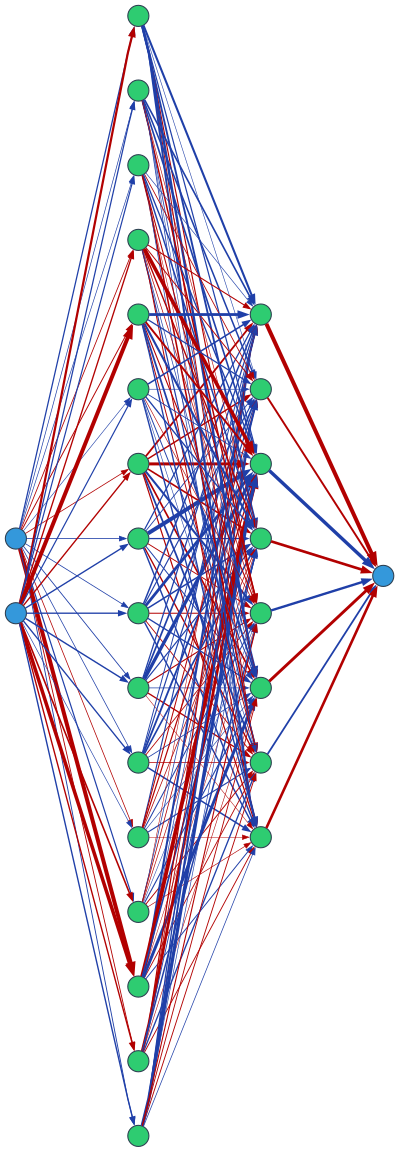
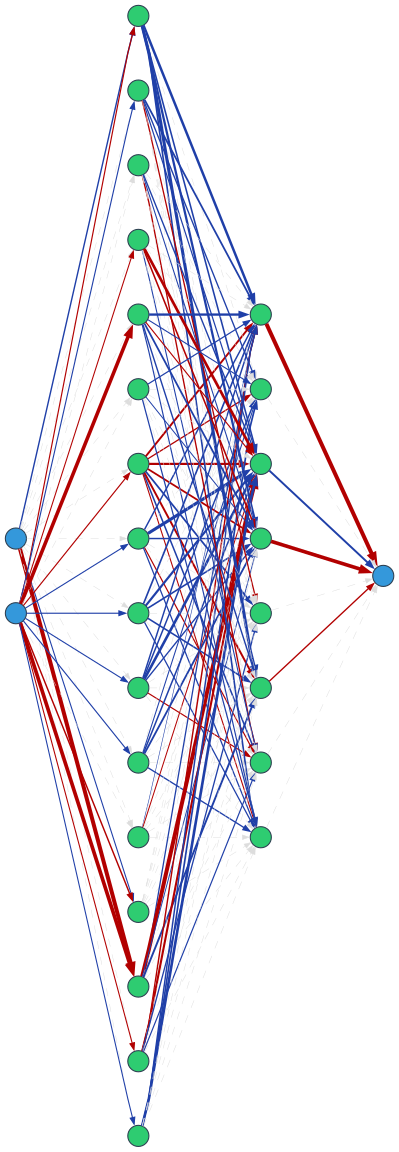

In [84]:
print("baseline sparsity:", round(kernel_sparsity(baseline), 4))
print("pruned_50 sparsity:", round(kernel_sparsity(pruned_50), 4))

base_path = (
    NetworkArchitectureVisualizer
    .from_keras_model(baseline, weight_styling=True)
    .render(filename=str(VIZ_DIR / "arch_baseline_weighted"))
)
pruned_path = (
    NetworkArchitectureVisualizer
    .from_keras_model(pruned_50, weight_styling=True)
    .render(filename=str(VIZ_DIR / "arch_pruned"))
)

print("Wrote:", base_path)
print("Wrote:", pruned_path)

# display baseline and pruned side by side
PRUNE_VIZ_WIDTH = 520

cols = "1fr 1fr"
cell_style = "text-align:center;"
label_style = "font-family:monospace;font-size:14px;color:#333;margin-bottom:6px;"

html = f"""
<div style='display:grid;grid-template-columns:{cols};gap:18px;align-items:start;'>
  <div style='{cell_style}'>
    <div style='{label_style}'>baseline (full)</div>
    <img src='{_embed_data_uri(base_path)}' style='width:{PRUNE_VIZ_WIDTH}px;height:auto;' />
  </div>
  <div style='{cell_style}'>
    <div style='{label_style}'>pruned 50%</div>
    <img src='{_embed_data_uri(pruned_path)}' style='width:{PRUNE_VIZ_WIDTH}px;height:auto;' />
  </div>
</div>
"""

display(HTML(html))

### 4.2 — Knowledge Distillation

**Idea.** A small student model is trained to imitate a larger
*teacher's* output probabilities (the "soft targets"). The teacher's
soft labels carry more information than the hard 0/1 labels alone,
so a *capacity-limited* student often beats one trained from scratch.


In [85]:
def distill(teacher, student, X, y, *, epochs=80, batch_size=128, alpha=0.5, T=2.0):
    """Combine BCE on hard labels with MSE on softened sigmoid outputs."""
    bce = keras.losses.BinaryCrossentropy()
    opt = keras.optimizers.Adam(1e-2)

    X_t = tf.convert_to_tensor(X)
    y_t = tf.convert_to_tensor(y.reshape(-1, 1), dtype=tf.float32)
    n = len(X)

    for _ in range(epochs):
        idx = RNG.permutation(n)
        for i in range(0, n, batch_size):
            j = idx[i : i + batch_size]
            xb = tf.gather(X_t, j); yb = tf.gather(y_t, j)
            t_prob = teacher(xb, training=False)
            t_logit = tf.math.log(t_prob / (1 - t_prob + 1e-7) + 1e-7)
            t_soft = tf.sigmoid(t_logit / T)
            with tf.GradientTape() as tape:
                s_prob = student(xb, training=True)
                s_logit = tf.math.log(s_prob / (1 - s_prob + 1e-7) + 1e-7)
                s_soft = tf.sigmoid(s_logit / T)
                hard = bce(yb, s_prob)
                soft = tf.reduce_mean(tf.square(s_soft - t_soft)) * (T ** 2)
                loss = (1 - alpha) * hard + alpha * soft
            grads = tape.gradient(loss, student.trainable_variables)
            opt.apply_gradients(zip(grads, student.trainable_variables))
    return student


# Teacher = an over-parameterized network. (This was already trained
# in the section-5-style sweep above; retrain here so the section is
# self-contained.)
keras.utils.set_random_seed(506)
teacher = build_model([32, 16], BASELINE_ACTIVATION)
fit_model(teacher, X_train, y_train, epochs=200)

# Pick a deliberately weak student: small width AND saturating activation.
# Trained from scratch on hard labels alone, this student should under-perform
# the teacher noticeably -- which is the regime where distillation helps.
STUDENT_HIDDEN = [4]
STUDENT_ACTIVATION = "sigmoid"

keras.utils.set_random_seed(7)
student_alone = build_model(STUDENT_HIDDEN, STUDENT_ACTIVATION)
fit_model(student_alone, X_train, y_train, epochs=200)

keras.utils.set_random_seed(7)
student_distilled = build_model(STUDENT_HIDDEN, STUDENT_ACTIVATION)
student_distilled = distill(
    teacher, student_distilled, X_train, y_train,
    epochs=200, alpha=0.7, T=3.0,
)

distill_summary = pd.DataFrame([
    {"model": "teacher (32,16) tanh", "params": teacher.count_params(),
     "test_acc": accuracy(teacher, X_test, y_test)},
    {"model": f"student {STUDENT_HIDDEN} {STUDENT_ACTIVATION} (no distill)",
     "params": student_alone.count_params(),
     "test_acc": accuracy(student_alone, X_test, y_test)},
    {"model": f"student {STUDENT_HIDDEN} {STUDENT_ACTIVATION} (distilled)",
     "params": student_distilled.count_params(),
     "test_acc": accuracy(student_distilled, X_test, y_test)},
]).round(4)
distill_summary

,model,params,test_acc
0,"teacher (32,16) tanh",641,0.958
1,student [4] sigmoid (no distill),17,0.936
2,student [4] sigmoid (distilled),17,0.928


### 4.3 — Low-Rank Factorization

**Idea.** A trained Dense layer has a weight matrix $W \in
\mathbb{R}^{d_\text{in}\times d_\text{out}}$. If $W \approx U_r S_r
V_r^\top$ (truncated SVD at rank $r$), we can replace the layer by **two
thin Dense layers** of total size $r(d_\text{in} + d_\text{out})$ — a
big win when $r \ll \min(d_\text{in}, d_\text{out})$. A short fine-tune
restores accuracy. Even on small networks this technique illustrates
the principle, which scales directly to massive layers in real models.

In [86]:
def svd_factorize_first_dense(model: keras.Sequential, rank: int) -> keras.Sequential:
    """Replace `model.layers[0]` (Dense) with two Dense layers of rank `r`."""
    first = model.layers[0]
    W, b = first.get_weights()
    activation = first.activation
    in_dim = W.shape[0]; out_dim = W.shape[1]
    r = min(rank, min(W.shape))

    U, S, Vt = np.linalg.svd(W, full_matrices=False)
    Ur = U[:, :r]; Sr = S[:r]; Vtr = Vt[:r, :]

    f1 = layers.Dense(r, activation="linear", use_bias=False, input_dim=in_dim)
    f2 = layers.Dense(out_dim, activation=activation, use_bias=True)
    new_model = keras.Sequential([f1, f2] + list(model.layers[1:]))
    new_model.build((None, in_dim))

    f1.set_weights([Ur])
    f2.set_weights([(np.diag(Sr) @ Vtr), b])
    new_model.compile(optimizer=keras.optimizers.Adam(1e-2), loss="binary_crossentropy")
    return new_model


# Train a wider 1-hidden-layer net so the rank story is visible.
keras.utils.set_random_seed(506)
wide = build_model([32], BASELINE_ACTIVATION)
fit_model(wide, X_train, y_train, epochs=120)
wide_acc = accuracy(wide, X_test, y_test)
wide_params = int(wide.count_params())

lr_rows = []
for r in [1, 2, 4, 8, 16]:
    fact = svd_factorize_first_dense(wide, rank=r)
    pre = accuracy(fact, X_test, y_test)
    fit_model(fact, X_train, y_train, epochs=30)  # short fine-tune
    post = accuracy(fact, X_test, y_test)
    lr_rows.append({
        "rank": r,
        "params": int(fact.count_params()),
        "test_acc_after_factorize": pre,
        "test_acc_after_finetune": post,
    })

print(f"Wide reference: params={wide_params}, test_acc={wide_acc:.3f}")
pd.DataFrame(lr_rows).round(4)

Wide reference: params=129, test_acc=0.956


,rank,params,test_acc_after_factorize,test_acc_after_finetune
0,1,99,0.808,0.830
1,2,133,0.956,0.956
2,4,133,0.956,0.956
3,8,133,0.956,0.956
4,16,133,0.956,0.956


> **TODO 3 — Compare the techniques.**
>
> Fill in the table below using your numbers. Which technique gave you
> the **best test accuracy per parameter** for the spirals problem?
> Explain in 2–3 sentences why you think that is (think about: how much
> redundancy each technique can exploit; whether spirals data has the
> structure that technique assumes).
>
> | Technique           | params  | test_acc | acc / param |
> |---------------------|---------|----------|-------------|
> | Sweep best          | 9       | 0.920    | 0.1022      |
> | Pruning (50%)       | 109\*   | 0.956    | 0.0088      |
> | Distilled student   | 17      | 0.928    | 0.0546      |
> | Low-rank (best `r`) | 133     | 0.956    | 0.0072      |
>
> <sub>\* Pruning starts from the `[16, 8]` baseline (193 total params:
> 168 kernel weights + 25 biases). 50% kernel sparsity zeros out half the
> kernel weights but does not touch biases, so the effective non-zero
> parameter count is 168 / 2 + 25 = 109. We use this effective count
> because pruning's pedagogical point is reducing real arithmetic, not
> the parameter-object count Keras reports.</sub>
>
> _Reference answer:_ The from-scratch architecture sweep wins by a wide
> margin on the spirals problem because the optimal architecture
> (a 2-unit tanh hidden layer) is already at the floor of what's needed
> to separate the two spiral arms — two tanh units are enough to carve a
> smooth curved boundary. The other three techniques all start from a
> deliberately oversized baseline and only *trim* parameters: they can
> match the sweep's accuracy, but they can't get below the sweep's
> parameter count, so their `acc/param` is much lower. The takeaway: on
> a small, well-understood problem, **searching the architecture itself
> dominates any post-hoc compression** — minimization techniques pay off
> most when you already have a large pretrained model whose architecture
> you can't easily change.

## 5. Putting It All Together — Final Minimal Model


Baseline  : hidden=[16, 8], activation=tanh, params=193, test_acc=0.958
Final     : hidden=[2], activation=tanh, params=9, test_acc=0.928
Compression ratio: 21.4×


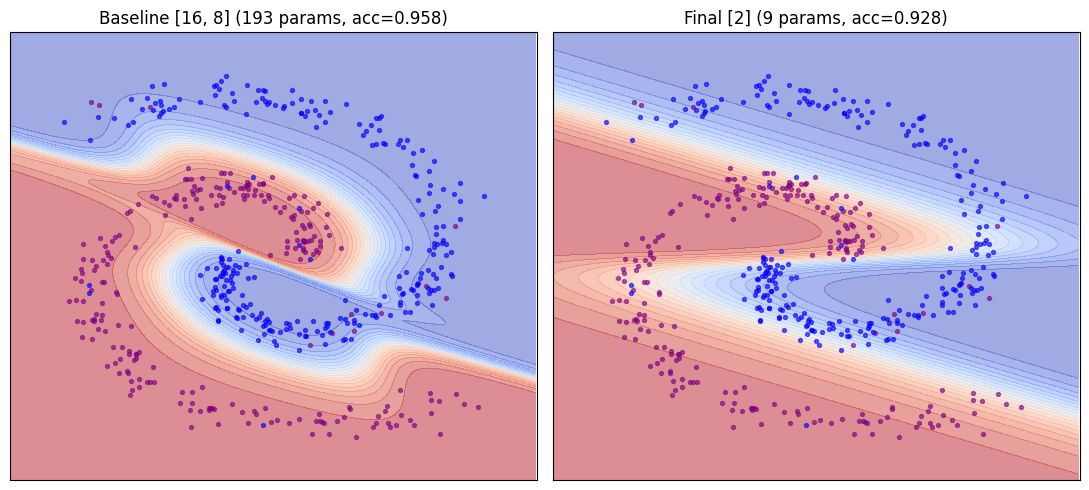

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Wrote: arch_final.png, final_activations.gif into visualizations


"baseline [16, 8] tanh",final [2] tanh
,

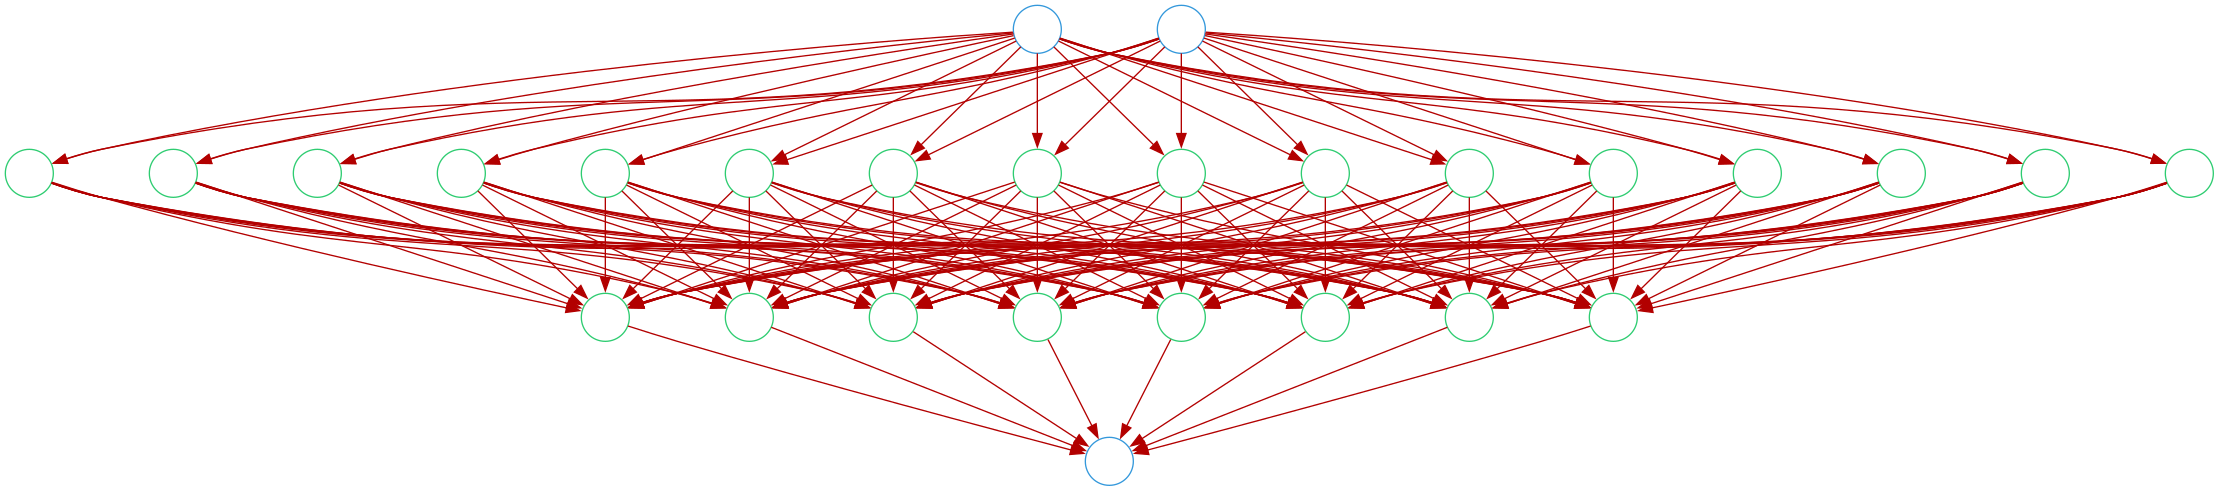
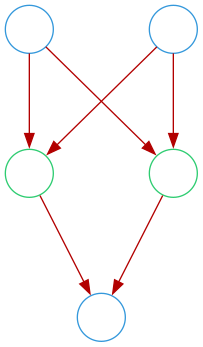

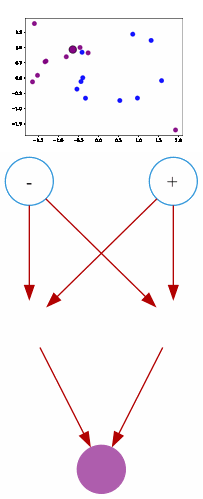

In [87]:
# Build the final minimal model: optimal activation × optimal architecture.
keras.utils.set_random_seed(506)
final_model = build_model(OPT_HIDDEN, OPT_ACTIVATION)
fit_model(final_model, X_train, y_train, epochs=200)

final_acc = accuracy(final_model, X_test, y_test)
final_params = int(final_model.count_params())

print(f"Baseline  : hidden={BASELINE_HIDDEN}, activation={BASELINE_ACTIVATION}, "
      f"params={baseline_params}, test_acc={baseline_acc:.3f}")
print(f"Final     : hidden={OPT_HIDDEN}, activation={OPT_ACTIVATION}, "
      f"params={final_params}, test_acc={final_acc:.3f}")
print(f"Compression ratio: {baseline_params / final_params:.1f}×")

# Decision boundary side-by-side.
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_decision_boundary(baseline, X_test, y_test, axes[0],
                       title=f"Baseline {BASELINE_HIDDEN} ({baseline_params} params, acc={baseline_acc:.3f})")
plot_decision_boundary(final_model, X_test, y_test, axes[1],
                       title=f"Final {OPT_HIDDEN} ({final_params} params, acc={final_acc:.3f})")
plt.tight_layout()
plt.show()

# kviz visualizations of the final model.
viz_final = Visualizer(final_model)
viz_final.render(filename=str(VIZ_DIR / "arch_final"))
viz_final.view_activations_for(
    X_view, y_view, filename=str(VIZ_DIR / "final_activations"), duration=300,
)
print("Wrote: arch_final.png, final_activations.gif into", str(VIZ_DIR))

# Display: baseline vs final architecture (top row) and the final
# activation animation (bottom).
show_grid(
    rows=[[str(VIZ_DIR / "arch_baseline.png"), str(VIZ_DIR / "arch_final.png")]],
    headers=[f"baseline {BASELINE_HIDDEN} {BASELINE_ACTIVATION}",
             f"final {OPT_HIDDEN} {OPT_ACTIVATION}"],
    max_width=400,
)
display(HTML("<div style='font-family:monospace;font-size:12px;color:#666;margin-top:6px;'>final neuron activations:</div>"))
display(Image(filename=str(VIZ_DIR / "final_activations.gif")))

## 6. Reflection (short answers)

Answer each question below in **1–3 sentences**. These reinforce the
intuition that the slides + visualizations are designed to build.

**R1.** Looking at the activation animations, what does a "dead ReLU
neuron" look like? Did your final model have any?

**R2.** Compare `visualizations/arch_baseline_weighted.png` with `visualizations/arch_pruned.png`.
Which inputs / hidden-units lost the most connections? Does that match
which directions of `X_train` you'd guess matter most?

**R3.** Why does knowledge distillation often produce a student that
beats *training the same architecture from scratch* on hard targets?
What information is the teacher providing that the raw labels don't?

**R4.** When would low-rank factorization be most useful, and when
would it *not* help much? (Hint: think about the rank of the trained
weight matrix.)

**R5.** Considering everything you've seen, write down the rule of
thumb you'd use to pick (i) an activation function and (ii) a hidden
layer size if you were given a brand-new 2D classification problem you
hadn't seen before.